In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r'C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv')

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

Using device: cuda

Origin 1/6 — 2025-07-01
Forecast horizon: 744 hours
Training on 20727 sequences...
  Epoch 1/100 — train_loss: 0.2068 — val_loss: 0.5102 — lr: 0.001000
  Epoch 10/100 — train_loss: 0.0260 — val_loss: 0.3207 — lr: 0.001000
  Early stopping triggered at epoch 16
  Done — 744 hours forecasted

Origin 2/6 — 2025-08-01
Forecast horizon: 744 hours
Training on 21471 sequences...
  Epoch 1/100 — train_loss: 0.1623 — val_loss: 0.3354 — lr: 0.001000
  Epoch 10/100 — train_loss: 0.0191 — val_loss: 0.3153 — lr: 0.000500
  Early stopping triggered at epoch 14
  Done — 744 hours forecasted

Origin 3/6 — 2025-09-01
Forecast horizon: 720 hours
Training on 22239 sequences...
  Epoch 1/100 — train_loss: 0.1482 — val_loss: 0.2667 — lr: 0.001000
  Epoch 10/100 — train_loss: 0.0196 — val_loss: 0.3068 — lr: 0.000500
  Early stopping triggered at epoch 11
  Done — 720 hours forecasted

Origin 4/6 — 2025-10-01
Forecast horizon: 744 hours
Training on 22935 sequences...
  Epoch 1/100 — train

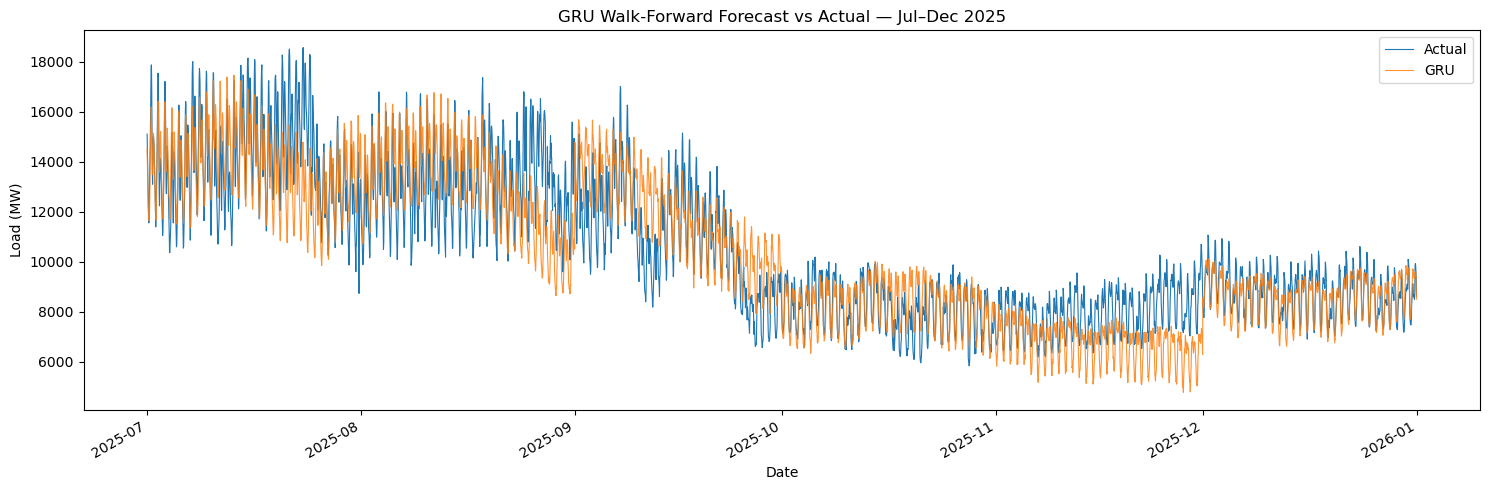

MlflowException: API request to http://127.0.0.1:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=Electricity_Load_Forecasting (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x000002012B5CD6A0>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it'))

In [4]:
import copy
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 0) FEATURES
# ============================================================
df = df.copy()
df['Post_Break'] = (df.index >= '2024-07-01').astype(int)

feature_cols = [
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48',
    'rolling_mean_168', 'rolling_std_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos'
]
target_col = 'load'
SEQ_LEN = 250  # one month lookback

# ============================================================
# 1) MODEL
# ============================================================
class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3, output_size=744):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

# ============================================================
# 2) SEQUENCE BUILDER
# ============================================================
def make_sequences(data_x, data_y, seq_len, horizon):
    X, y = [], []
    max_i = len(data_x) - seq_len - horizon + 1
    for i in range(max_i):
        X.append(data_x[i : i + seq_len])
        y.append(data_y[i + seq_len : i + seq_len + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# ============================================================
# 3) TRAINING FUNCTION
# ============================================================
def train_gru(
    X_tr, y_tr, input_size, horizon,
    epochs=100, batch_size=32,
    patience=10, min_delta=1e-4
):
    n = len(X_tr)
    split_idx = int(n * 0.85)

    X_train, X_val = X_tr[:split_idx], X_tr[split_idx:]
    y_train, y_val = y_tr[:split_idx], y_tr[split_idx:]

    model = GRUForecaster(
        input_size=input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        output_size=horizon
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4
    )
    criterion = nn.MSELoss()

    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train), torch.tensor(y_train)
    )
    val_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_val), torch.tensor(y_val)
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False
    )

    best_val_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(epochs):
        # training
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validation
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(
                f"  Epoch {epoch+1}/{epochs} — "
                f"train_loss: {train_loss:.4f} — "
                f"val_loss: {val_loss:.4f} — "
                f"lr: {lr_now:.6f}"
            )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping triggered at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# 4) WALK-FORWARD LOOP
# ============================================================
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_gru = []
actuals_gru = []

for i, origin in enumerate(origins):
    print(f"\n{'='*60}")
    print(f"Origin {i+1}/6 — {origin.date()}")

    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    horizon = len(df.loc[origin:month_end])
    print(f"Forecast horizon: {horizon} hours")

    train_df = df.loc[: origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_scaled = scaler_x.fit_transform(train_df[feature_cols].values)
    y_scaled = scaler_y.fit_transform(
        train_df[target_col].values.reshape(-1, 1)
    ).ravel()

    X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN, horizon)
    print(f"Training on {len(X_seq)} sequences...")

    model = train_gru(
        X_seq, y_seq,
        input_size=len(feature_cols),
        horizon=horizon,
        epochs=100,
        batch_size=32,
        patience=10
    )

    model.eval()
    with torch.no_grad():
        window = df.loc[
            origin - pd.Timedelta(hours=SEQ_LEN) : origin - pd.Timedelta(hours=1)
        ].dropna(subset=feature_cols)

        x_in = scaler_x.transform(window[feature_cols].values)
        x_in = torch.tensor(x_in[np.newaxis], dtype=torch.float32).to(device)

        pred_scaled = model(x_in).cpu().numpy().ravel()
        pred_mw = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

    actual_month = df.loc[origin:month_end, target_col]
    pred_series = pd.Series(pred_mw[:len(actual_month)], index=actual_month.index)

    preds_gru.append(pred_series)
    actuals_gru.append(actual_month)

    print(f"  Done — {len(actual_month)} hours forecasted")

# ============================================================
# 5) METRICS
# ============================================================
pred_gru = pd.concat(preds_gru).sort_index()
actual_gru = pd.concat(actuals_gru).sort_index()

mae  = np.mean(np.abs(actual_gru - pred_gru))
rmse = np.sqrt(np.mean((actual_gru - pred_gru) ** 2))
mape = np.mean(np.abs((actual_gru - pred_gru) / actual_gru)) * 100

print(f"\nGRU Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 6) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_gru.index, actual_gru.values, label="Actual", linewidth=0.8)
ax.plot(pred_gru.index, pred_gru.values, label="GRU", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("GRU Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# 7) MLFLOW LOGGING
# ============================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Load_Forecasting")

with mlflow.start_run(run_name="GRU_monthly_output"):
    mlflow.log_param("model", "GRU")
    mlflow.log_param("forecast_horizon", "monthly_direct_output")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("seq_len", SEQ_LEN)
    mlflow.log_param("features", str(feature_cols))
    mlflow.log_param("hidden_size", 128)
    mlflow.log_param("num_layers", 2)
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("max_epochs", 100)
    mlflow.log_param("patience", 10)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_param("scheduler", "ReduceLROnPlateau")
    mlflow.log_param("gradient_clipping", 1.0)
    mlflow.log_param("post_break_feature", True)

    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("MAPE", float(mape))

    fig.savefig("gru_forecast.png")
    mlflow.log_artifact("gru_forecast.png")

    pred_vs_actual = pd.DataFrame({
        "actual": actual_gru,
        "predicted": pred_gru
    })
    pred_vs_actual.to_csv("gru_predictions.csv")
    mlflow.log_artifact("gru_predictions.csv")


Origin 1/24 — 2025-12-31 00:00:00
  Train rows: 26112
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025-12-31 00:00:00

Origin 2/24 — 2025-12-31 01:00:00
  Train rows: 26113
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025-12-31 01:00:00

Origin 3/24 — 2025-12-31 02:00:00
  Train rows: 26114
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025-12-31 02:00:00

Origin 4/24 — 2025-12-31 03:00:00
  Train rows: 26115
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025-12-31 03:00:00

Origin 5/24 — 2025-12-31 04:00:00
  Train rows: 26116
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025-12-31 04:00:00

Origin 6/24 — 2025-12-31 05:00:00
  Train rows: 26117
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025-12-31 05:00:00

Origin 7/24 — 2025-12-31 06:00:00
  Train rows: 26118
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025-12-31 06:00:00

Origin 8/24 — 2025-12-31 07:00:00
  Train rows: 26119
  Test rows: 1
  Horizon: 1 hour
  Done — predicted 2025

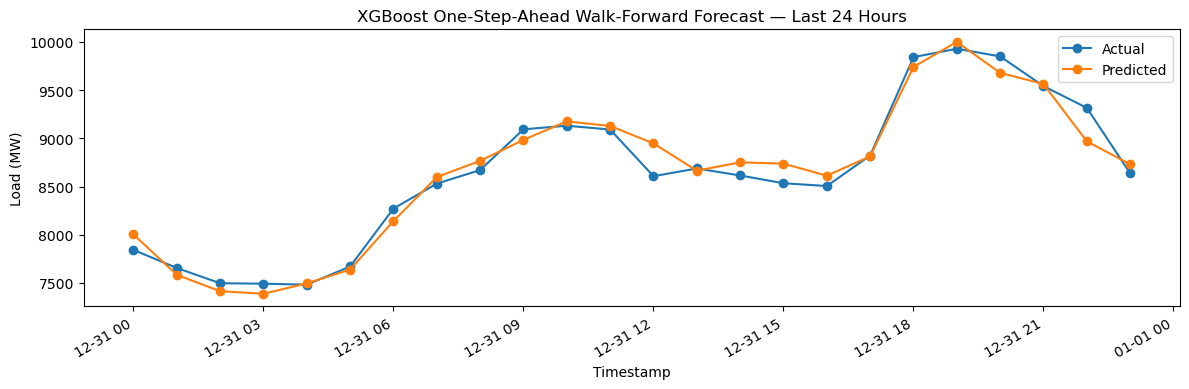

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

feature_cols = [
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48',
    'rolling_mean_168', 'rolling_std_168',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'hour', 'day_of_week', 'month', 'year'
]
target_col = 'load'

# ------------------------------------------------------------
# WALK-FORWARD SETTINGS
# ------------------------------------------------------------
horizon = 1   # one-step ahead
last_ts = df.index.max()
test_start = last_ts - pd.Timedelta(hours=23)
origins = df.loc[test_start:last_ts].index   # 24 hourly origins

preds = []
actuals = []

xgb_params = {
    "n_estimators": 400,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
}

for i, origin in enumerate(origins):
    print(f"\n{'='*50}")
    print(f"Origin {i+1}/24 — {origin}")

    # -------------------------
    # TRAIN SET
    # everything before origin
    # -------------------------
    train_df = df.loc[: origin - pd.Timedelta(hours=1)].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    # -------------------------
    # TEST SET
    # only the single hour at origin
    # -------------------------
    test_df = df.loc[[origin]].dropna(
        subset=feature_cols + [target_col]
    ).copy()

    if len(test_df) == 0:
        print("  Skipped — missing row")
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    print(f"  Train rows: {len(X_train)}")
    print(f"  Test rows: {len(X_test)}")
    print(f"  Horizon: {horizon} hour")

    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]

    preds.append(pd.Series([pred], index=y_test.index))
    actuals.append(y_test)

    print(f"  Done — predicted {origin}")

pred_xgb = pd.concat(preds).sort_index()
actual_xgb = pd.concat(actuals).sort_index()

mae  = np.mean(np.abs(actual_xgb - pred_xgb))
rmse = np.sqrt(np.mean((actual_xgb - pred_xgb) ** 2))
mape = np.mean(np.abs((actual_xgb - pred_xgb) / actual_xgb)) * 100

print(f"\nXGBoost One-Step Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual_xgb.index, actual_xgb.values, label='Actual', marker='o')
ax.plot(pred_xgb.index, pred_xgb.values, label='Predicted', marker='o')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Load (MW)')
ax.set_title('XGBoost One-Step-Ahead Walk-Forward Forecast — Last 24 Hours')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()